IMPORTS

In [54]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
TABLES_DIR = BASE_DIR / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RFM_PATH = PROCESSED_DIR / "rfm_features.csv"
BEHAVIOUR_PATH = PROCESSED_DIR / "rfm_refined_advanced_features.csv"

print("Setup complete.")

Setup complete.


LOAD FEATURE DATASET

In [55]:
rfm = pd.read_csv(RFM_PATH)
behaviour = pd.read_csv(BEHAVIOUR_PATH)

print("RFM shape:", rfm.shape)
print("Refined behavioural shape:", behaviour.shape)

display(rfm.head())
display(behaviour.head())

RFM shape: (4338, 4)
Refined behavioural shape: (4338, 9)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


,CustomerID,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV
0,12346,326,1,77183.60,1,1.000000,0.000000,1.000000,0.000000
1,12347,2,7,4310.00,366,0.019126,18.478817,0.051338,0.553943
2,12348,75,4,1797.24,283,0.014134,70.149840,0.014055,0.670272
3,12349,19,1,1757.55,1,1.000000,0.000000,1.000000,0.000000
4,12350,310,1,334.40,1,1.000000,0.000000,1.000000,0.000000


FEATURE MATRICES

In [56]:
rfm_features = [
    "Recency",
    "Frequency",
    "Monetary"
]

behaviour_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Customer_Lifetime_Days",
    "Purchase_Velocity",
    "Purchase_Interval_Std",
    "Purchase_Regularity_Index",
    "Invoice_Value_CV"
]

rfm_data = rfm[rfm_features]
behaviour_data = behaviour[behaviour_features]

print("RFM features:", rfm_data.columns.tolist())
print("Behavioural features:", behaviour_data.columns.tolist())

print("RFM data shape:", rfm_data.shape)
print("Behavioural data shape:", behaviour_data.shape)

RFM features: ['Recency', 'Frequency', 'Monetary']
Behavioural features: ['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Velocity', 'Purchase_Interval_Std', 'Purchase_Regularity_Index', 'Invoice_Value_CV']
RFM data shape: (4338, 3)
Behavioural data shape: (4338, 8)


PREPROCESSING FUNCTION

In [57]:
def cap_outliers_iqr(data):
    capped = data.copy()

    for col in capped.columns:
        q1 = capped[col].quantile(0.25)
        q3 = capped[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        capped[col] = capped[col].clip(lower=lower, upper=upper)

    return capped


def preprocess_features(data):
    processed = cap_outliers_iqr(data)

    log_columns = [
        "Frequency",
        "Monetary",
        "Customer_Lifetime_Days",
        "Purchase_Velocity",
        "Purchase_Interval_Std"
    ]

    for col in log_columns:
        if col in processed.columns:
            processed[col] = np.log1p(processed[col])

    scaler = RobustScaler()
    scaled = scaler.fit_transform(processed)

    return scaled

APPLY PREPROCESSING

In [58]:
rfm_scaled = preprocess_features(rfm_data)
behaviour_scaled = preprocess_features(behaviour_data)

print("Preprocessing completed.")
print("RFM scaled shape:", rfm_scaled.shape)
print("Behavioural scaled shape:", behaviour_scaled.shape)

Preprocessing completed.
RFM scaled shape: (4338, 3)
Behavioural scaled shape: (4338, 8)


OUTLIER CAPPINGK SELECTION

In [59]:
K_RANGE = range(2, 11)

k_results = []

for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(behaviour_scaled)

    k_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette_Score": silhouette_score(behaviour_scaled, labels)
    })

k_results_df = pd.DataFrame(k_results)

k_results_df.to_csv(
    TABLES_DIR / "k_selection_results_refined_behavioural.csv",
    index=False
)

display(k_results_df)

,K,Inertia,Silhouette_Score
0,2,5574.719777,0.460086
1,3,4092.305974,0.427232
2,4,3218.898022,0.436734
3,5,2773.026485,0.355459
4,6,2475.969272,0.363952
5,7,2265.753113,0.363492
6,8,2062.859909,0.369717
7,9,1915.475834,0.370810
8,10,1794.361541,0.331938


ELBOW GRAPGH

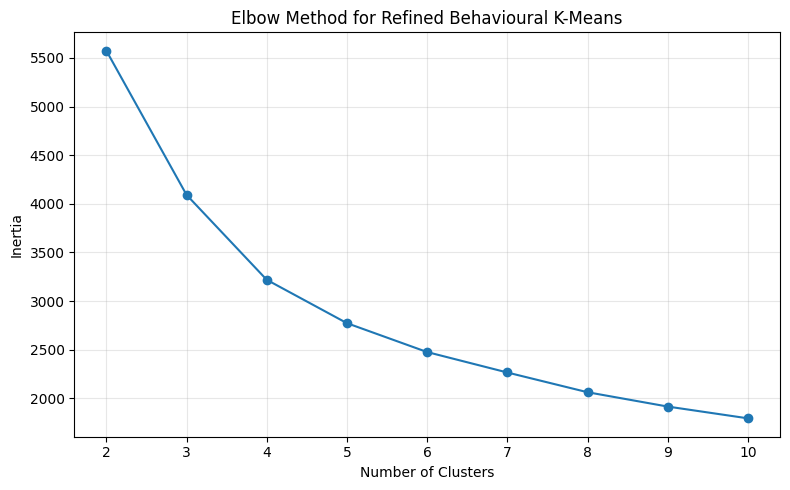

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df["K"],
    k_results_df["Inertia"],
    marker="o"
)

plt.title("Elbow Method for Refined Behavioural K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "elbow_method_refined_behavioural.png",
    dpi=300
)

plt.show()

SILHOUETTE GRAPGH

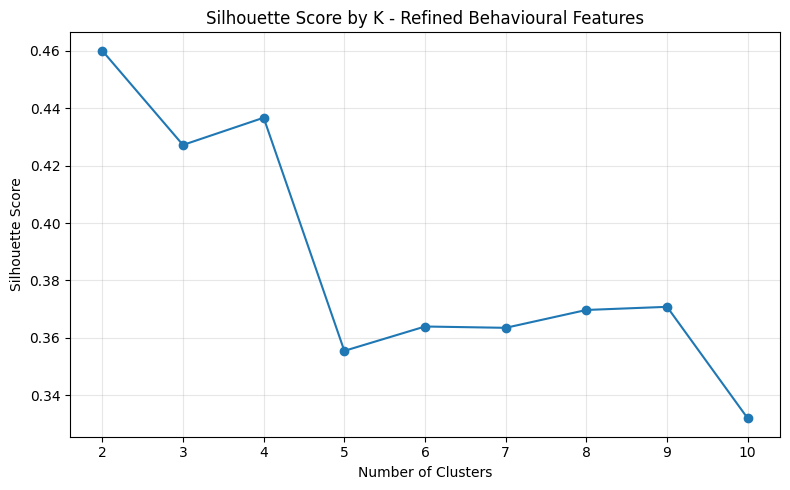

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df["K"],
    k_results_df["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by K - Refined Behavioural Features")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "silhouette_refined_behavioural.png",
    dpi=300
)

plt.show()

FINAL K SELECTION

In [62]:
best_k_by_silhouette = int(
    k_results_df.loc[
        k_results_df["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_score = k_results_df["Silhouette_Score"].max()

print("Best K by Silhouette:", best_k_by_silhouette)
print("Best Silhouette Score:", round(best_score, 4))

K_VALUE = 4

print("Final K selected for dissertation:", K_VALUE)

Best K by Silhouette: 2
Best Silhouette Score: 0.4601
Final K selected for dissertation: 4


K MEANS CLUSTERING

In [63]:
kmeans_rfm = KMeans(
    n_clusters=K_VALUE,
    random_state=42,
    n_init=10
)

rfm["KMeans_Cluster"] = kmeans_rfm.fit_predict(rfm_scaled)

kmeans_behaviour = KMeans(
    n_clusters=K_VALUE,
    random_state=42,
    n_init=10
)

behaviour["KMeans_Cluster"] = kmeans_behaviour.fit_predict(behaviour_scaled)

print("K-Means completed.")
print("K value used:", K_VALUE)

print("\nRFM K-Means cluster distribution:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())

print("\nRefined Behavioural K-Means cluster distribution:")
print(behaviour["KMeans_Cluster"].value_counts().sort_index())

K-Means completed.
K value used: 4

RFM K-Means cluster distribution:
KMeans_Cluster
0     993
1     965
2    1053
3    1327
Name: count, dtype: int64

Refined Behavioural K-Means cluster distribution:
KMeans_Cluster
0     856
1    1943
2     780
3     759
Name: count, dtype: int64


HIERARCHICAL GRAPGH

In [64]:
hier_rfm = AgglomerativeClustering(
    n_clusters=K_VALUE,
    linkage="ward"
)

rfm["Hierarchical_Cluster"] = hier_rfm.fit_predict(rfm_scaled)

hier_behaviour = AgglomerativeClustering(
    n_clusters=K_VALUE,
    linkage="ward"
)

behaviour["Hierarchical_Cluster"] = hier_behaviour.fit_predict(behaviour_scaled)

print("Hierarchical clustering completed.")

print("\nRFM Hierarchical cluster distribution:")
print(rfm["Hierarchical_Cluster"].value_counts().sort_index())

print("\nRefined Behavioural Hierarchical cluster distribution:")
print(behaviour["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical clustering completed.

RFM Hierarchical cluster distribution:
Hierarchical_Cluster
0    1849
1     900
2     840
3     749
Name: count, dtype: int64

Refined Behavioural Hierarchical cluster distribution:
Hierarchical_Cluster
0     990
1    1838
2     816
3     694
Name: count, dtype: int64


GMM GRAPGH

In [65]:
gmm_rfm = GaussianMixture(
    n_components=K_VALUE,
    covariance_type="full",
    random_state=42
)

rfm["GMM_Cluster"] = gmm_rfm.fit_predict(rfm_scaled)

gmm_behaviour = GaussianMixture(
    n_components=K_VALUE,
    covariance_type="full",
    random_state=42
)

behaviour["GMM_Cluster"] = gmm_behaviour.fit_predict(behaviour_scaled)

print("GMM clustering completed.")

print("\nRFM GMM cluster distribution:")
print(rfm["GMM_Cluster"].value_counts().sort_index())

print("\nRefined Behavioural GMM cluster distribution:")
print(behaviour["GMM_Cluster"].value_counts().sort_index())

GMM clustering completed.

RFM GMM cluster distribution:
GMM_Cluster
0    1493
1     881
2    1410
3     554
Name: count, dtype: int64

Refined Behavioural GMM cluster distribution:
GMM_Cluster
0     765
1    1586
2    1493
3     494
Name: count, dtype: int64


PCA VISUALISATION

PCA explained variance:
PC1: 0.6467
PC2: 0.1483
Total: 0.795


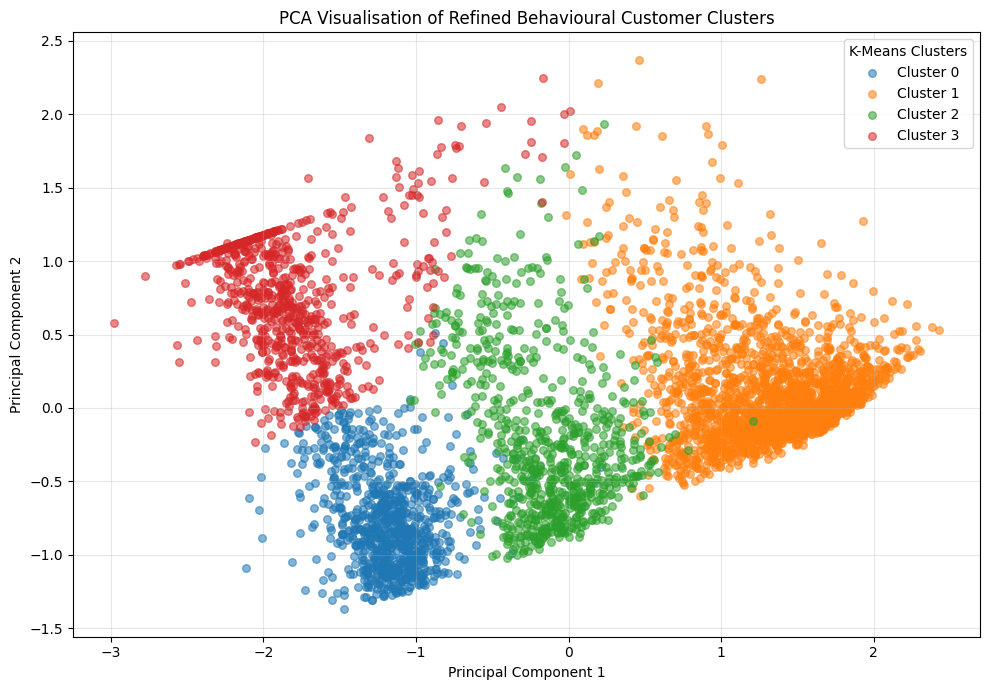

In [66]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(behaviour_scaled)

pca_df = pd.DataFrame({
    "PCA1": pca_result[:, 0],
    "PCA2": pca_result[:, 1],
    "Cluster": behaviour["KMeans_Cluster"].astype(int)
})

print("PCA explained variance:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.55,
        s=30
    )

plt.title("PCA Visualisation of Refined Behavioural Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Clusters")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pca_refined_behavioural_clusters.png",
    dpi=300
)

plt.show()

CLUSTER DISTRIBUTION CHART

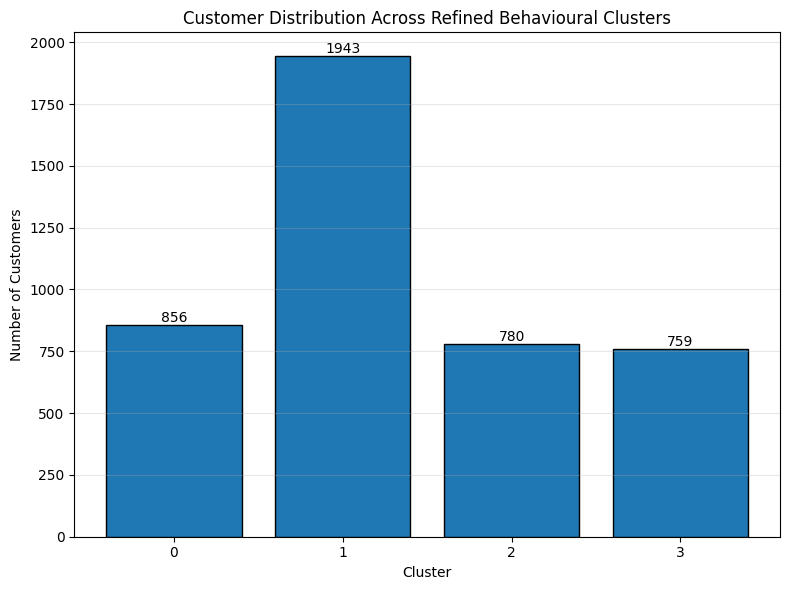

In [67]:
cluster_counts = behaviour["KMeans_Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution Across Refined Behavioural Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "refined_behavioural_cluster_distribution.png",
    dpi=300
)

plt.show()

CLSUTER PROFILE

In [68]:
cluster_profile = (
    behaviour
    .groupby("KMeans_Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean",
        "Customer_Lifetime_Days": "mean",
        "Purchase_Velocity": "mean",
        "Purchase_Interval_Std": "mean",
        "Purchase_Regularity_Index": "mean",
        "Invoice_Value_CV": "mean"
    })
    .round(2)
)

display(cluster_profile)

cluster_profile.to_csv(
    TABLES_DIR / "refined_behavioural_cluster_profile.csv"
)

,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV
KMeans_Cluster,,,,,,,,
0,62.80,1.05,425.47,1.02,1.04,0.00,1.00,0.03
1,41.26,7.78,3824.56,241.08,0.04,42.66,0.04,0.52
2,77.31,2.07,972.93,124.44,0.08,0.30,0.96,0.39
3,272.99,1.19,438.72,5.08,0.97,0.16,0.99,0.06


SAVE CLUSTER DATA SET 

In [69]:
rfm_output_path = PROCESSED_DIR / "rfm_clustered.csv"
behaviour_output_path = PROCESSED_DIR / "rfm_refined_behavioural_clustered.csv"

rfm.to_csv(rfm_output_path, index=False)
behaviour.to_csv(behaviour_output_path, index=False)

print("Saved clustered datasets:")
print(rfm_output_path)
print(behaviour_output_path)

Saved clustered datasets:
..\data\processed\rfm_clustered.csv
..\data\processed\rfm_refined_behavioural_clustered.csv


FINAL SUMMARY EXPLANATION

In [70]:
print("="*80)
print("FINAL CLUSTERING MODEL SUMMARY")
print("="*80)

print("Dataset Used                : UCI Online Retail")
print(f"Number of Customers         : {len(rfm)}")
print(f"Final K Selected            : {K_VALUE}")

print("\nFeature Sets")
print("-------------")
print(f"Traditional RFM Features    : {len(rfm_features)}")
print(f"Refined Behavioural Features: {len(behaviour_features)}")

print("\nAlgorithms Implemented")
print("----------------------")
print("✓ K-Means")
print("✓ Hierarchical Clustering")
print("✓ Gaussian Mixture Model")

print("\nPreprocessing Applied")
print("---------------------")
print("✓ IQR Outlier Capping")
print("✓ Log Transformation")
print("✓ Robust Scaling")

print("\nGenerated Outputs")
print("-----------------")
print("✓ k_selection_results_refined_behavioural.csv")
print("✓ refined_behavioural_cluster_profile.csv")
print("✓ rfm_clustered.csv")
print("✓ rfm_refined_behavioural_clustered.csv")

print("="*80)
print("05_clustering_models.ipynb COMPLETED SUCCESSFULLY")
print("="*80)

FINAL CLUSTERING MODEL SUMMARY
Dataset Used                : UCI Online Retail
Number of Customers         : 4338
Final K Selected            : 4

Feature Sets
-------------
Traditional RFM Features    : 3
Refined Behavioural Features: 8

Algorithms Implemented
----------------------
✓ K-Means
✓ Hierarchical Clustering
✓ Gaussian Mixture Model

Preprocessing Applied
---------------------
✓ IQR Outlier Capping
✓ Log Transformation
✓ Robust Scaling

Generated Outputs
-----------------
✓ k_selection_results_refined_behavioural.csv
✓ refined_behavioural_cluster_profile.csv
✓ rfm_clustered.csv
✓ rfm_refined_behavioural_clustered.csv
05_clustering_models.ipynb COMPLETED SUCCESSFULLY
